In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
amazon_market_data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Lesson14/amazon_market_data.csv')

In [ ]:
amazon_market_data

,Order Date,Row ID,Order ID,Ship Mode,Customer ID,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,30-12-20,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,30-12-20,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,30-12-20,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,30-12-20,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


Приведение столбцов к стилю camel_case

In [ ]:
import re

df = amazon_market_data.copy()

def to_camel_case(s):
    # 1. убираем лишние подчёркивания
    s = re.sub(r'_+', '_', s)

    # 2. убираем подчёркивания по краям
    s = s.strip('_')

    # 3. разбиваем на слова по _
    parts = s.split('_')

    # 4. если это уже camelCase (например transactionId)
    if len(parts) == 1:
        parts = re.findall(r'[A-Z]?[a-z]+|[A-Z]+|\d+', s)

    # 5. первое слово маленькое, остальные с большой
    parts[0] = parts[0].lower()
    parts[1:] = [p.capitalize() for p in parts[1:]]

    return '_'.join(parts)

amazon_market_data.columns = [to_camel_case(col) for col in df.columns]

In [ ]:
amazon_market_data

,order_Date,row_Id,order_Id,ship_Mode,customer_Id,segment,country,city,state,postal_Code,region,product_Id,category,sub_Category,product_Name,sales,quantity,discount,profit
0,01-01-20,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,01-01-20,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,01-01-20,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,01-01-20,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,01-01-20,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,30-12-20,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,30-12-20,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,30-12-20,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,30-12-20,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


Приведение типов данных

In [ ]:
amazon_market_data['order_Date'] = pd.to_datetime(
    amazon_market_data['order_Date'],
    format='%d-%m-%y'
)

In [ ]:
amazon_market_data['order_Date'].head()
amazon_market_data['order_Date'].dtype

dtype('<M8[ns]')

In [ ]:
amazon_market_data

,order_Date,row_Id,order_Id,ship_Mode,customer_Id,segment,country,city,state,postal_Code,region,product_Id,category,sub_Category,product_Name,sales,quantity,discount,profit
0,2020-01-01,849,CA-2017-107503,Standard Class,GA-14725,Consumer,United States,Lorain,Ohio,44052,East,FUR-FU-10003878,Furniture,Furnishings,"Linden 10"" Round Wall Clock, Black",48.896,4,0.2,8.5568
1,2020-01-01,4010,CA-2017-144463,Standard Class,SC-20725,Consumer,United States,Los Angeles,California,90036,West,FUR-FU-10001215,Furniture,Furnishings,"Howard Miller 11-1/2"" Diameter Brentwood Wall ...",474.430,11,0.0,199.2606
2,2020-01-01,6683,CA-2017-154466,First Class,DP-13390,Home Office,United States,Franklin,Wisconsin,53132,Central,OFF-BI-10002012,Office Supplies,Binders,Wilson Jones Easy Flow II Sheet Lifters,3.600,2,0.0,1.7280
3,2020-01-01,8070,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,454.560,5,0.2,-107.9580
4,2020-01-01,8071,CA-2017-151750,Standard Class,JM-15250,Consumer,United States,Huntsville,Texas,77340,Central,FUR-FU-10002116,Furniture,Furnishings,"Tenex Carpeted, Granite-Look or Clear Contempo...",141.420,5,0.6,-187.3815
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3307,2020-12-30,908,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,TEC-PH-10004774,Technology,Phones,Gear Head AU3700S Headset,90.930,7,0.0,2.7279
3308,2020-12-30,909,CA-2017-143259,Standard Class,PO-18865,Consumer,United States,New York City,New York,10009,East,OFF-BI-10003684,Office Supplies,Binders,Wilson Jones Legal Size Ring Binders,52.776,3,0.2,19.7910
3309,2020-12-30,1297,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10002103,Office Supplies,Binders,"Cardinal Slant-D Ring Binder, Heavy Gauge Vinyl",13.904,2,0.2,4.5188
3310,2020-12-30,1298,CA-2017-115427,Standard Class,EB-13975,Corporate,United States,Fairfield,California,94533,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,20.720,2,0.2,6.4750


Поиск дублей и пропусков в данных

In [ ]:
df.isna().sum()

,0
Order Date,0
Row ID,0
Order ID,0
Ship Mode,0
Customer ID,0
Segment,0
Country,0
City,0
State,0
Postal Code,0


In [ ]:
df.duplicated().sum()

np.int64(0)

#Исследовательский анализ данных:

Количество уникальных заказов и уникальных клиентов в таблице

In [ ]:
print(f"Уникальных заказов: {unique_orders}")
print(f"Уникальных клиентов: {unique_customers}")

Уникальных заказов: 1687
Уникальных клиентов: 693


Локация пользователей

In [ ]:
region_orders = amazon_market_data.groupby('region')['order_Id'].nunique().sort_values(ascending=False)

state_orders = amazon_market_data.groupby('state')['order_Id'].nunique().sort_values(ascending=False)

city_orders = amazon_market_data.groupby('city')['order_Id'].nunique().sort_values(ascending=False)

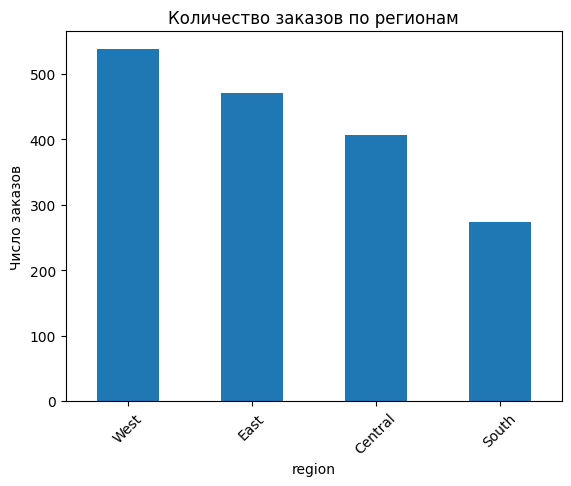

In [ ]:
import matplotlib.pyplot as plt

region_orders.plot(kind='bar')
plt.title('Количество заказов по регионам')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

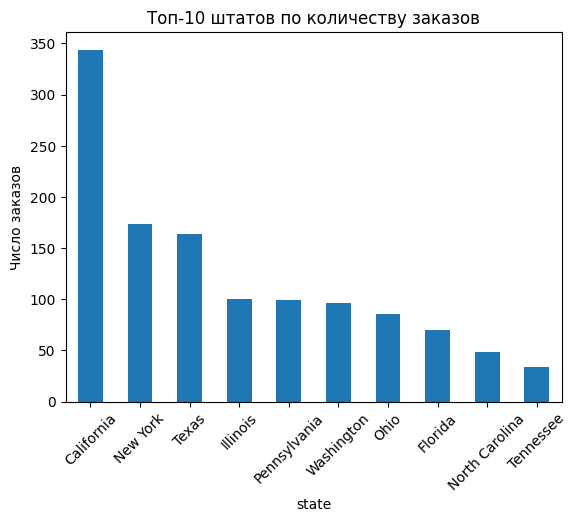

In [ ]:
state_orders.head(10).plot(kind='bar')
plt.title('Топ-10 штатов по количеству заказов')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

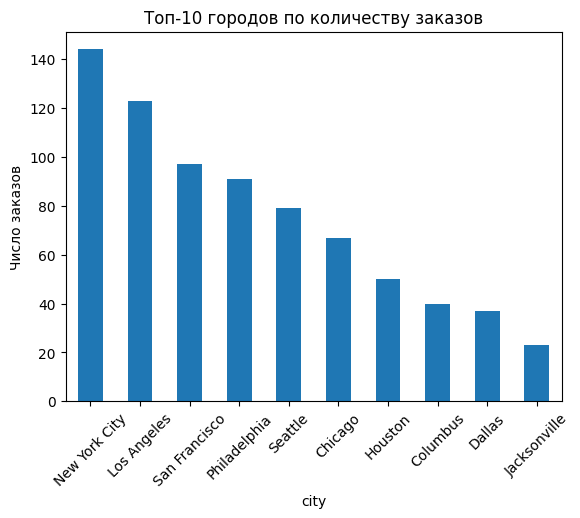

In [ ]:
city_orders.head(10).plot(kind='bar')
plt.title('Топ-10 городов по количеству заказов')
plt.ylabel('Число заказов')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ распределения заказов по географическим признакам показывает выраженную неравномерность. На уровне регионов наибольшее количество заказов приходится на западный регион, который значительно опережает остальные. Наименьшее количество заказов наблюдается в южном регионе, что может свидетельствовать о меньшей активности клиентов.
При рассмотрении распределения по штатам видно, что абсолютным лидером является California с существенным отрывом от других штатов. Далее следуют New York и Texas, также демонстрируя высокий уровень заказов.
Анализ по городам подтверждает эту тенденцию: наибольшее количество заказов приходится на крупнейшие мегаполисы, такие как New York City, Los Angeles и San Francisco. За ними следуют другие крупные города, включая Philadelphia, Seattle и Chicago. При этом даже внутри топ-10 наблюдается спад к менее крупным городам, таким как Jacksonville, где количество заказов значительно ниже.

Динамика количества заказов по дате заказов

In [ ]:
daily_orders = amazon_market_data.groupby('order_Date')['order_Id'].nunique()

In [ ]:
monthly_orders = amazon_market_data.groupby(
    amazon_market_data['order_Date'].dt.to_period('M')
)['order_Id'].nunique()

In [ ]:
monthly_orders.index = monthly_orders.index.to_timestamp()

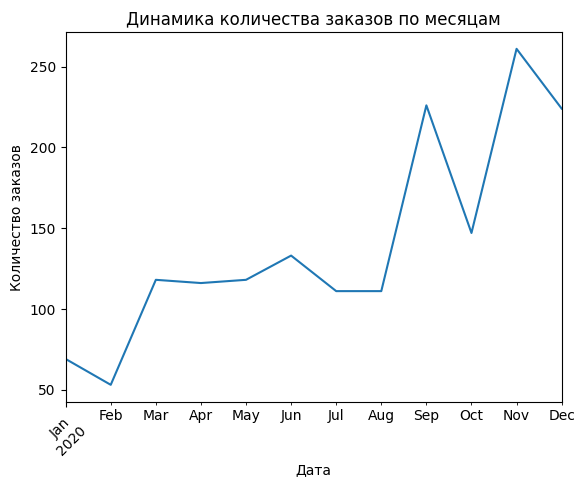

In [ ]:
import matplotlib.pyplot as plt

monthly_orders.plot()
plt.title('Динамика количества заказов по месяцам')
plt.ylabel('Количество заказов')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ динамики количества заказов по месяцам показывает неравномерное поведение спроса в течение года с выраженными периодами роста и спада.
В начале года наблюдается снижение: после января происходит падение в феврале, где фиксируется одно из минимальных значений. Далее с марта начинается устойчивый рост, который продолжается до июня, что может указывать на постепенное восстановление спроса после начала года.
В летние месяцы (июль–август) наблюдается небольшой спад — количество заказов немного снижается и держится примерно на одном уровне. Однако уже в сентябре происходит резкий скачок вверх, что свидетельствует о начале активного сезона.
В ноябре достигается максимальное значение за весь период — пик заказов, после чего в декабре происходит небольшое снижение
Таким образом, можно выделить общий восходящий тренд с ярко выраженной сезонностью: спад в начале года, умеренный рост весной, небольшое затишье летом и резкий рост в осенне-зимний период с пиком в ноябре.

Динамика продаж по сумме

In [ ]:
monthly_sales = amazon_market_data.groupby(
    amazon_market_data['order_Date'].dt.to_period('M')
)['sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

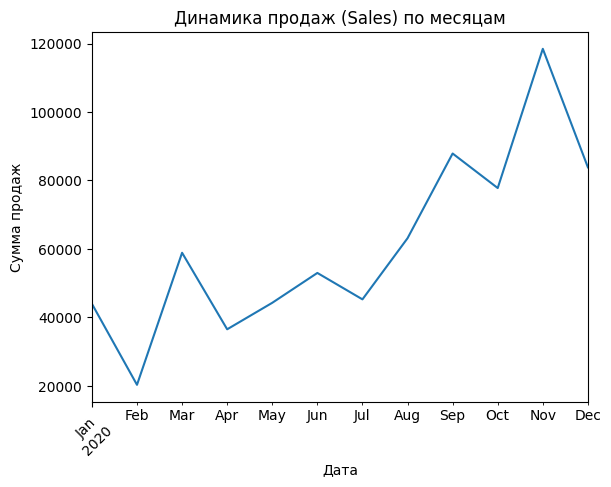

In [ ]:
import matplotlib.pyplot as plt

monthly_sales.plot()
plt.title('Динамика продаж (Sales) по месяцам')
plt.ylabel('Сумма продаж')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ динамики продаж по месяцам показывает выраженные колебания выручки в течение года с общей тенденцией к росту и ярко выраженной сезонностью.
В начале года наблюдается снижение: после января происходит резкое падение в феврале, где фиксируется минимальное значение продаж. Уже в марте происходит значительный рост, однако в апреле снова наблюдается спад. В период с мая по июнь выручка постепенно увеличивается, после чего в июле вновь фиксируется небольшое снижение.
Начиная с августа начинается устойчивый рост продаж, который продолжается до сентября. В октябре наблюдается кратковременное снижение, однако уже в ноябре достигается максимальное значение за весь период — пик продаж. В декабре происходит заметное снижение по сравнению с ноябрём, но уровень выручки остаётся выше среднего по году.
Таким образом, динамика продаж демонстрирует общий восходящий тренд с колебаниями: спад в начале года, нестабильность весной и летом и выраженный рост в осенне-зимний период с пиком в ноябре.

Распределение продаж по категориям заказов

In [ ]:
category_sales = amazon_market_data.groupby('category')['sales'].sum().sort_values(ascending=False)

subcategory_sales = amazon_market_data.groupby('sub_Category')['sales'].sum().sort_values(ascending=False)

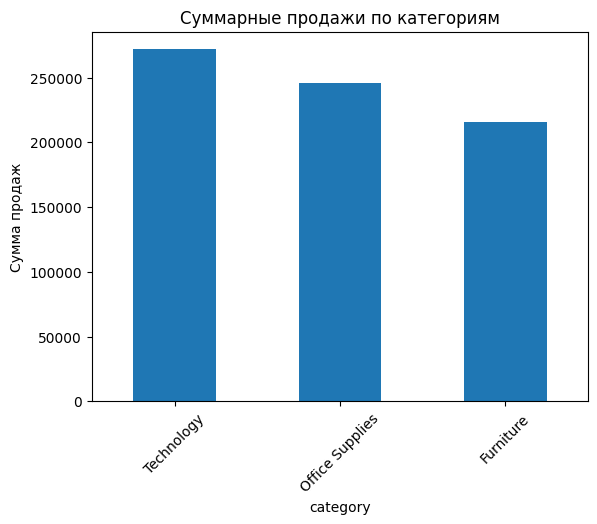

In [ ]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')
plt.title('Суммарные продажи по категориям')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.show()

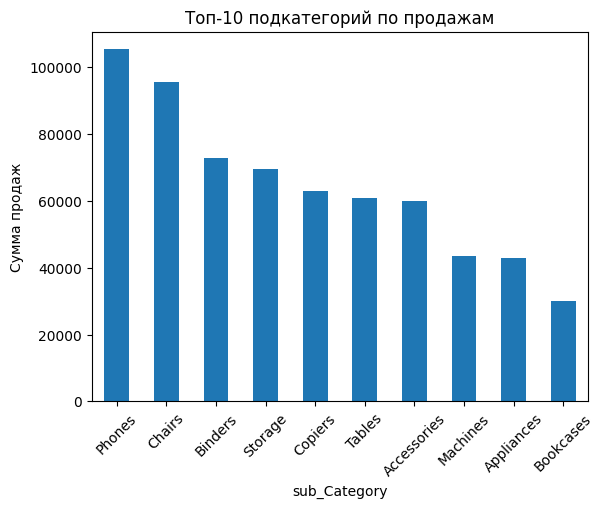

In [ ]:
subcategory_sales.head(10).plot(kind='bar')
plt.title('Топ-10 подкатегорий по продажам')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ распределения продаж по категориям показывает, что лидером является категория Technology, которая формирует наибольшую долю выручки. На втором месте находится категория Office Supplies, немного уступающая лидеру, а наименьший объём продаж наблюдается в категории Furniture, которая замыкает список.
При более детальном рассмотрении подкатегорий видно, что наибольшие продажи приходятся на Phones, которые занимают первое место с заметным отрывом. Далее следуют Chairs, Binders и Storage, также демонстрируя высокие значения выручки. Средние позиции занимают такие подкатегории, как Copiers, Tables и Accessories.
В конце списка находятся подкатегории с наименьшими продажами — Machines, Appliances и Bookcases, причём Bookcases показывают минимальное значение среди представленных.
Таким образом, можно сделать вывод, что основная выручка компании формируется за счёт ограниченного числа подкатегорий, в первую очередь связанных с технологическими товарами и офисной продукцией, тогда как часть ассортимента приносит существенно меньший вклад в общие продажи.

Рапределение продаж по городам (штатам)

In [ ]:
# Продажи по регионам
region_sales = amazon_market_data.groupby('region')['sales'].sum().sort_values(ascending=False)

# Продажи по штатам
state_sales = amazon_market_data.groupby('state')['sales'].sum().sort_values(ascending=False)

# Продажи по городам
city_sales = amazon_market_data.groupby('city')['sales'].sum().sort_values(ascending=False)

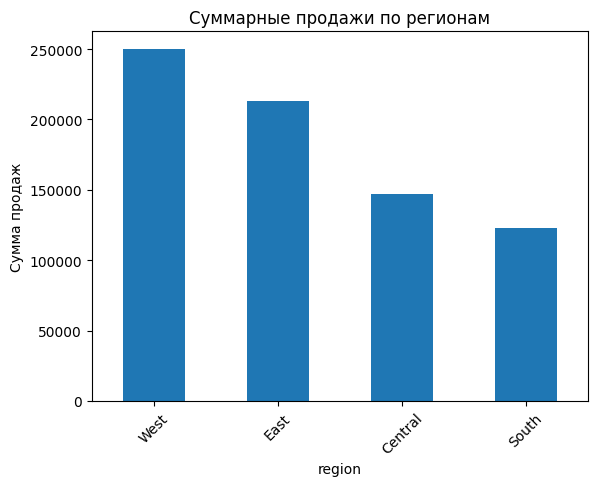

In [ ]:
import matplotlib.pyplot as plt

region_sales.plot(kind='bar')
plt.title('Суммарные продажи по регионам')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.show()

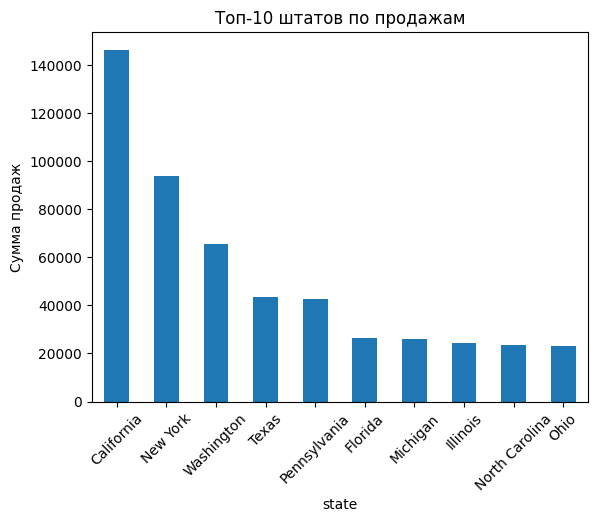

In [ ]:
state_sales.head(10).plot(kind='bar')
plt.title('Топ-10 штатов по продажам')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.show()

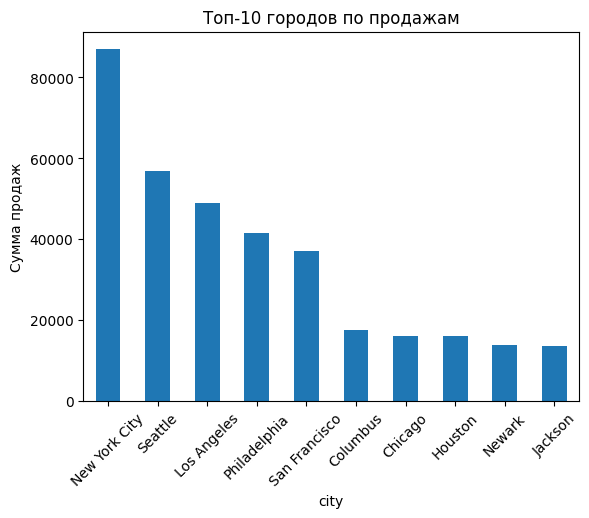

In [ ]:
city_sales.head(10).plot(kind='bar')
plt.title('Топ-10 городов по продажам')
plt.ylabel('Сумма продаж')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ распределения продаж по регионам показывает, что наибольшая выручка приходится на западный регион. Далее следует восточный регион, демонстрируя также высокий уровень продаж. Южный показывают значительно более низкие значения, причём он является наименее прибыльным регионом.
Распределение по штатам подтверждает эту тенденцию: абсолютным лидером является California, которая с большим отрывом опережает остальные штаты. За ней следуют New York и Washington, формируя группу наиболее прибыльных регионов. Остальные штаты из топ-10, такие как Texas, Pennsylvania и Florida, демонстрируют умеренные значения продаж.
Анализ на уровне городов показывает, что основная выручка сосредоточена в крупнейших городах. Лидером является New York City, значительно опережающий остальные города. Далее следуют Seattle, Los Angeles и Philadelphia. Остальные города из топ-10, включая San Francisco, Chicago и Houston, имеют заметно меньшие показатели, а такие города, как Newark и Jackson, замыкают список.
В целом прослеживается чёткая закономерность: продажи концентрируются в экономически развитых регионах, штатах и крупных городах с высокой плотностью населения.

Самые популярные товары

In [ ]:
product_orders = amazon_market_data.groupby('product_Name')['order_Id'].nunique().sort_values(ascending=False)

In [ ]:
top_products = product_orders.head(10)

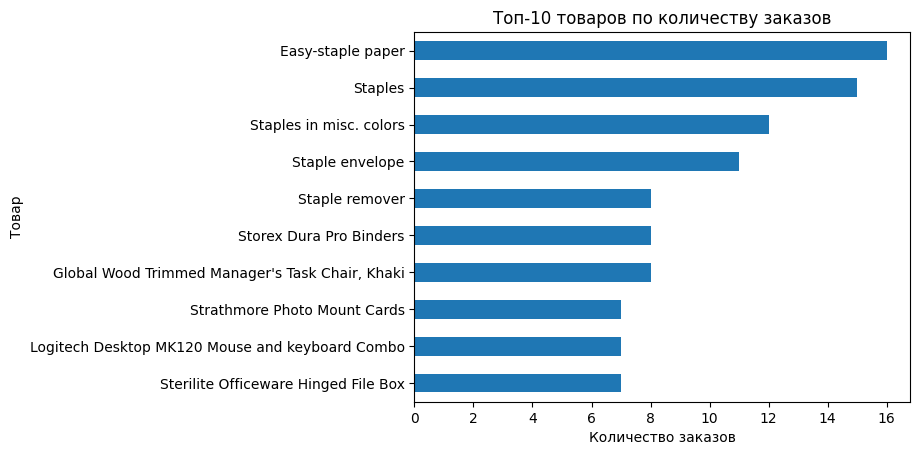

In [ ]:
import matplotlib.pyplot as plt

top_products.sort_values().plot(kind='barh')
plt.title('Топ-10 товаров по количеству заказов')
plt.xlabel('Количество заказов')
plt.ylabel('Товар')
plt.show()

Вывод: Анализ популярности товаров показывает, что спрос в значительной степени сосредоточен на товарах повседневного офисного использования, при этом лидируют недорогие и регулярно используемые позиции.
Наиболее популярным товаром является Easy-staple paper (бумага для степлера / офисная бумага), который имеет наибольшее количество заказов. На втором месте находится Staples (скобы для степлера), что логично дополняет лидера и указывает на высокий спрос на расходные материалы для офиса. Далее следует Staples in misc. colors (скобы разных цветов), также относящиеся к категории офисных расходников.
Среди менее массовых, но всё ещё популярных товаров можно выделить:
Global Wood Trimmed Manager's Task Chair, Khaki (офисное кресло менеджера, цвет хаки)
Strathmore Photo Mount Cards (карточки для фотомонтажа)
Logitech Desktop MK120 Mouse and Keyboard Combo (комплект клавиатура + мышь Logitech)
Sterilite Officeware Hinged File Box (ящик для хранения документов)

Таким образом, можно сделать вывод, что основную долю заказов формируют недорогие, часто используемые офисные товары (бумага, скобы, папки), которые регулярно закупаются в больших объёмах. Более дорогие товары, такие как мебель или техника, также присутствуют в списке, но уступают по частоте заказов.

Распределение категорий внутри городов (штатов)

In [ ]:
city_category_orders = amazon_market_data.groupby(
    ['city', 'category']
)['order_Id'].nunique().reset_index()

In [ ]:
pivot_city_category = city_category_orders.pivot(
    index='city',
    columns='category',
    values='order_Id'
).fillna(0)

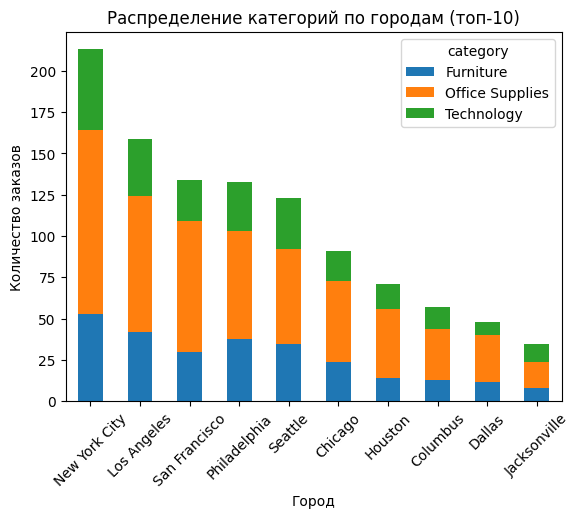

In [ ]:
top_cities = amazon_market_data.groupby('city')['order_Id'].nunique().sort_values(ascending=False).head(10).index

pivot_city_category.loc[top_cities].plot(kind='bar', stacked=True)

plt.title('Распределение категорий по городам (топ-10)')
plt.ylabel('Количество заказов')
plt.xlabel('Город')
plt.xticks(rotation=45)
plt.show()

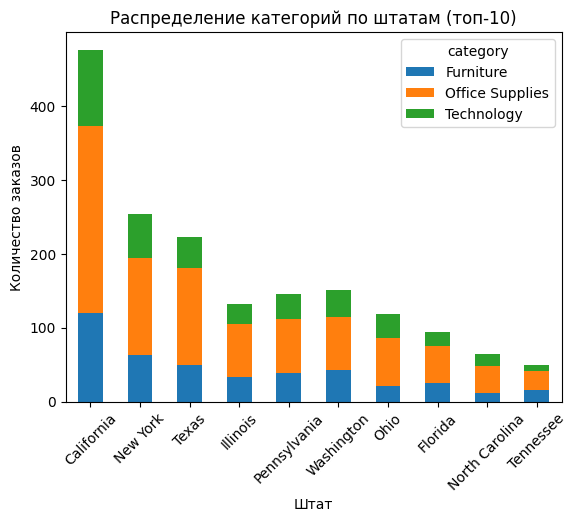

In [ ]:
state_category_orders = amazon_market_data.groupby(
    ['state', 'category']
)['order_Id'].nunique().reset_index()

pivot_state_category = state_category_orders.pivot(
    index='state',
    columns='category',
    values='order_Id'
).fillna(0)

top_states = amazon_market_data.groupby('state')['order_Id'].nunique().sort_values(ascending=False).head(10).index

pivot_state_category.loc[top_states].plot(kind='bar', stacked=True)

plt.title('Распределение категорий по штатам (топ-10)')
plt.ylabel('Количество заказов')
plt.xlabel('Штат')
plt.xticks(rotation=45)
plt.show()

Вывод: В разрезе городов видно, что во всех крупнейших городах — таких как New York City (Нью-Йорк), Los Angeles (Лос-Анджелес), San Francisco (Сан-Франциско) и Seattle (Сиэтл) — наибольшую долю заказов занимает категория Office Supplies (офисные принадлежности). Это указывает на высокий и стабильный спрос на расходные материалы для бизнеса и повседневной работы. На втором месте, как правило, находится категория Technology (технологии), особенно заметная в технологически развитых городах, таких как Сан-Франциско и Сиэтл, где её доля относительно выше. Категория Furniture (мебель) занимает наименьшую долю во всех городах, что объясняется более редкими покупками таких товаров.
Аналогичная картина наблюдается и на уровне штатов. В штате California (Калифорния), который является лидером по количеству заказов, доминирует категория Office Supplies (офисные принадлежности), при этом значительную долю также занимает Technology (технологии). В штатах New York (Нью-Йорк) и Texas (Техас) структура схожа, однако доля технологий несколько ниже, чем в Калифорнии.
В менее активных штатах, таких как North Carolina (Северная Каролина) и Tennessee (Теннесси), общее количество заказов ниже, а структура спроса более смещена в сторону офисных принадлежностей, при меньшем участии технологических товаров.

Динамика продаж внутри категорий

In [ ]:
category_monthly_sales = amazon_market_data.groupby(
    [amazon_market_data['order_Date'].dt.to_period('M'), 'category']
)['sales'].sum().unstack()

category_monthly_sales.index = category_monthly_sales.index.to_timestamp()

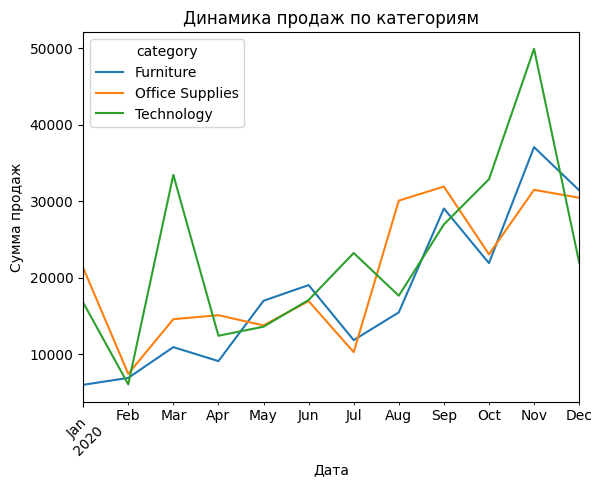

In [ ]:
category_monthly_sales.plot()
plt.title('Динамика продаж по категориям')
plt.ylabel('Сумма продаж')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.show()

In [ ]:
top_subcats = amazon_market_data.groupby('sub_Category')['sales'].sum().sort_values(ascending=False).head(5).index

subcat_monthly_sales = amazon_market_data[
    amazon_market_data['sub_Category'].isin(top_subcats)
].groupby(
    [amazon_market_data['order_Date'].dt.to_period('M'), 'sub_Category']
)['sales'].sum().unstack()

subcat_monthly_sales.index = subcat_monthly_sales.index.to_timestamp()

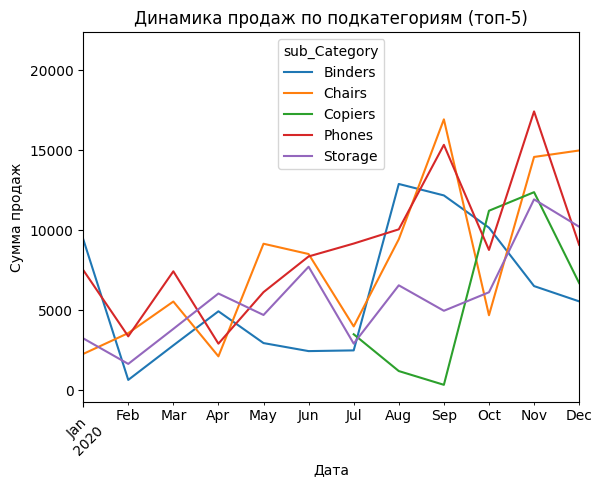

In [ ]:
subcat_monthly_sales.plot()
plt.title('Динамика продаж по подкатегориям (топ-5)')
plt.ylabel('Сумма продаж')
plt.xlabel('Дата')
plt.xticks(rotation=45)
plt.show()

Вывод: Анализ динамики продаж по категориям показывает, что все категории в целом следуют общей сезонности, однако отличаются по уровню продаж.
Категория Technology (технологии) демонстрирует наиболее выраженные колебания и самые высокие пики. После резкого падения в феврале наблюдается скачок в марте, затем умеренный рост с колебаниями летом и значительное увеличение продаж в осенний период.
Категория Office Supplies (офисные принадлежности) показывает более стабильную динамику. Несмотря на спад в феврале и июле, в целом наблюдается постепенный рост с выходом на высокие значения в сентябре–ноябре. Пик также приходится на осенний период, но без резких скачков.
У категории Furniture (мебель) после постепенного роста в первой половине года наблюдается спад в июле, затем значительный рост в сентябре и особенно в ноябре, где достигается максимум. В декабре происходит снижение.
При анализе подкатегорий видно, что разные группы товаров вносят разный вклад в общую динамику. Подкатегория Phones (телефоны) демонстрирует наиболее сильные пики, особенно в сентябре и ноябре, что усиливает общий рост категории Technology. Chairs (кресла) также показывают значительные колебания с пиком в сентябре и высоким уровнем в конце года.
Подкатегория Copiers (копировальная техника) имеет наиболее нестабильную динамику: после резкого падения летом (практически до нуля в августе–сентябре) наблюдается резкий рост в октябре–ноябре. Это может указывать на редкие, но крупные покупки.
Binders (папки) и Storage (системы хранения) демонстрируют более ровную динамику, хотя и с отдельными всплесками (например, рост в августе–сентябре и ноябре). Эти категории ближе к Office Supplies и отражают регулярный спрос.

Общий вывод:
В ходе анализа данных были выявлены несколько устойчивых закономерностей, характеризующих поведение клиентов, структуру продаж и сезонность спроса.

Во-первых, наблюдается сильная географическая концентрация заказов и выручки. Основной вклад в продажи вносят экономически развитые регионы — прежде всего западный (West) и восточный (East). Абсолютным лидером на уровне штатов является California, а на уровне городов — крупнейшие мегаполисы, такие как New York City, Los Angeles и San Francisco. При этом менее развитые регионы, особенно South, значительно отстают, что указывает на неравномерное распределение спроса.

Во-вторых, выявлена ярко выраженная сезонность как в количестве заказов, так и в выручке. Для обеих метрик характерны:
спад в начале года (особенно в феврале),
постепенный рост весной,
относительная стагнация летом,
резкий рост в осенний период,
пик в ноябре,
небольшое снижение в декабре.

Таким образом, можно говорить о восходящем тренде с сезонными колебаниями.

В-третьих, продажи имеют структурную концентрацию по категориям и товарам. Лидером является категория Technology, за ней следует Office Supplies, а Furniture занимает наименьшую долю.

В-четвёртых, спрос по своей природе разделяется на два типа:
регулярный (стабильный) — характерен для офисных товаров (бумага, скобы, папки), которые покупаются часто и формируют базовый объём продаж;
эпизодический (волатильный) — характерен для техники и мебели, где покупки реже, но на более крупные суммы, что создаёт пики в динамике.